# AC Energy Forecasting AI Pipeline

Project name: **AC Energy Forecasting AI Pipeline**

Goal: predict `next_10min_kWh`, the energy expected to be consumed in the next 10-minute interval.

This notebook builds only the local AI/ML pipeline. It does not include a website, backend API, FastAPI service, Grafana dashboard, database connection, authentication, or Docker setup.

Current dataset: the Kaggle / UCI Appliances Energy Prediction Dataset. This is a **proxy household appliance energy dataset**, not AC-only data. It is used here to build and validate a 10-minute energy forecasting workflow before real AC-specific data is available.

Future goal: replace the proxy target with real AC-specific kWh from a smart plug, AC meter, or IoT power sensor.


## 1. Project Context and Data Note

The final system should predict air conditioner electricity consumption in kWh for the next 10 minutes. At this stage, real AC-specific sensor data is not available, so this notebook uses total household appliance energy as a proxy target.

For the proxy dataset:

- Original target column: `Appliances`
- Original unit: Wh
- Standardized energy column: `kWh = Appliances / 1000`
- Forecasting target: `next_10min_kWh = kWh.shift(-1)`

Important: this notebook should not be presented as a final AC-specific prediction model. It is an AI pipeline prototype that can later be connected to real AC telemetry.

Future AC-specific features may include `ac_status`, `set_temp`, `ac_mode`, `number_people_in_rooms`, `occupancy_count`, `room_size`, `fan_speed`, and `real_ac_kWh`. These columns are optional and are not required for the current proxy dataset.


## 2. Install / Import Libraries

This notebook uses `pandas`, `numpy`, `scikit-learn`, `matplotlib`, and `joblib`. It will try to import `xgboost`; if XGBoost is unavailable, the notebook continues with scikit-learn models only.


In [37]:
import json
import warnings
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    root_mean_squared_error = None

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    xgb = None
    XGBOOST_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print(f"XGBoost available: {XGBOOST_AVAILABLE}")


XGBoost available: True


## 3. Configuration

Place the Kaggle/UCI file named `energydata_complete.csv` inside `data/raw/` before running the notebook.


In [38]:
DATA_PATH = Path("data/raw/energydata_complete.csv")
TARGET_COLUMN = "next_10min_kWh"
TIME_COLUMN = "timestamp"
RESAMPLE_INTERVAL = "10min"

TRAIN_RATIO = 0.70
VALIDATION_RATIO = 0.15
TEST_RATIO = 0.15

PROCESSED_DATA_DIR = Path("data/processed")
MODEL_DIR = Path("models")
METRICS_DIR = Path("reports/metrics")
FIGURE_DIR = Path("reports/figures")
AUDIT_DIR = Path("reports/audit")

for output_dir in [PROCESSED_DATA_DIR, MODEL_DIR, METRICS_DIR, FIGURE_DIR, AUDIT_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

PROCESSED_DATA_PATH = PROCESSED_DATA_DIR / "standardized_proxy_energy_dataset.csv"
AUDIT_REPORT_PATH = AUDIT_DIR / "data_audit_report.json"
METRICS_PATH = METRICS_DIR / "model_metrics.json"

DATASET_NOTE = "Proxy dataset: total household appliance energy, not AC-specific kWh"

print("Configuration ready.")
print(f"Data path: {DATA_PATH}")
print(f"Processed data path: {PROCESSED_DATA_PATH}")


Configuration ready.
Data path: data\raw\energydata_complete.csv
Processed data path: data\processed\standardized_proxy_energy_dataset.csv


## 4. Load Dataset

This cell reads the raw CSV file, displays the first rows, shows the dataset shape, and lists the available columns. If the file is missing, the error message explains exactly where to place it.


In [39]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset file not found at {DATA_PATH.resolve()}. "
        "Please place energydata_complete.csv inside data/raw/ and rerun this cell."
    )

raw_df = pd.read_csv(DATA_PATH)

display(raw_df.head())
print(f"Shape: {raw_df.shape}")
print("Columns:")
print(list(raw_df.columns))


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,11-01-2016 17:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,17.166667,55.20,7.026667,84.256667,17.200000,41.626667,18.2,48.900000,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,11-01-2016 17:10,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,17.166667,55.20,6.833333,84.063333,17.200000,41.560000,18.2,48.863333,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,11-01-2016 17:20,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,17.166667,55.09,6.560000,83.156667,17.200000,41.433333,18.2,48.730000,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,11-01-2016 17:30,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,17.166667,55.09,6.433333,83.423333,17.133333,41.290000,18.1,48.590000,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,11-01-2016 17:40,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,17.200000,55.09,6.366667,84.893333,17.200000,41.230000,18.1,48.590000,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


Shape: (19735, 29)
Columns:
['date', 'Appliances', 'lights', 'T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'rv1', 'rv2']


## 5. Dataset Adapter

The adapter converts the proxy dataset into a standardized energy forecasting format. It creates AC-compatible column names without claiming that the dataset is AC-only.


In [40]:
def adapt_appliances_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """Adapt the Kaggle/UCI Appliances dataset into a standard energy forecasting schema.

    The standardized target pipeline is AC-compatible, but the source data remains
    household appliance energy data. This function preserves useful original columns
    so feature profiles can use them when available.
    """
    adapted = df.copy()

    required_source_columns = ["date", "Appliances"]
    missing_source_columns = [column for column in required_source_columns if column not in adapted.columns]
    if missing_source_columns:
        raise ValueError(
            "Missing required source columns for the proxy dataset: "
            f"{missing_source_columns}"
        )

    adapted[TIME_COLUMN] = pd.to_datetime(adapted["date"], errors="coerce")
    adapted["energy_Wh"] = pd.to_numeric(adapted["Appliances"], errors="coerce")
    adapted["kWh"] = adapted["energy_Wh"] / 1000.0

    standard_mapping = {
        "T1": "indoor_temp",
        "RH_1": "indoor_humidity",
        "T_out": "outdoor_temp",
        "RH_out": "outdoor_humidity",
    }

    for source_column, standard_column in standard_mapping.items():
        if source_column in adapted.columns:
            adapted[standard_column] = pd.to_numeric(adapted[source_column], errors="coerce")

    temp_columns = [column for column in ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9"] if column in adapted.columns]
    humidity_columns = [column for column in ["RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9"] if column in adapted.columns]

    if temp_columns:
        adapted["indoor_temp_avg"] = adapted[temp_columns].apply(pd.to_numeric, errors="coerce").mean(axis=1)
    if humidity_columns:
        adapted["indoor_humidity_avg"] = adapted[humidity_columns].apply(pd.to_numeric, errors="coerce").mean(axis=1)

    adapted = adapted.sort_values(TIME_COLUMN).reset_index(drop=True)
    return adapted


adapted_df = adapt_appliances_dataset(raw_df)

display(adapted_df.head())
print(f"Adapted shape: {adapted_df.shape}")
print("Standardized columns present:")
print([column for column in [TIME_COLUMN, "energy_Wh", "kWh", "indoor_temp", "indoor_humidity", "outdoor_temp", "outdoor_humidity", "indoor_temp_avg", "indoor_humidity_avg"] if column in adapted_df.columns])


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,timestamp,energy_Wh,kWh,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity,indoor_temp_avg,indoor_humidity_avg
0,01-02-2016 00:00,40,20,22.230,46.433333,21.290000,46.126667,21.700000,46.500000,19.29,49.700000,20.094444,53.103333,11.390000,99.9,18.981667,50.145000,21.700000,55.152222,17.290000,51.700000,11.5,755.500000,94.0,8.000000,27.000000,10.5,36.003944,36.003944,2016-01-02 00:00:00,40,0.04,22.230,46.433333,11.5,94.0,19.329568,55.417840
1,01-02-2016 00:10,50,10,22.200,46.433333,21.290000,46.200000,21.700000,46.500000,19.23,49.626667,20.011111,53.073333,11.390000,99.9,19.000000,50.200000,21.700000,55.571667,17.290000,51.760000,11.5,755.633333,93.5,8.166667,29.166667,10.4,46.708604,46.708604,2016-01-02 00:10:00,50,0.05,22.200,46.433333,11.5,93.5,19.312346,55.473889
2,01-02-2016 00:20,40,10,22.175,46.522500,21.260000,46.260000,21.666667,46.400000,19.20,49.590000,20.000000,53.061111,11.390000,99.9,19.000000,50.145000,21.700000,55.845000,17.290000,51.863333,11.5,755.766667,93.0,8.333333,31.333333,10.3,34.632194,34.632194,2016-01-02 00:20:00,40,0.04,22.175,46.522500,11.5,93.0,19.297963,55.509660
3,01-02-2016 00:30,50,10,22.100,46.590000,21.200000,46.260000,21.600000,46.400000,19.20,49.590000,20.000000,53.020000,11.390000,99.9,19.005556,50.236111,21.688889,55.994444,17.356667,51.790000,11.5,755.900000,92.5,8.500000,33.500000,10.3,44.429047,44.429047,2016-01-02 00:30:00,50,0.05,22.100,46.590000,11.5,92.5,19.282346,55.531173
4,01-02-2016 00:40,40,20,22.100,46.730000,21.166667,46.400000,21.600000,46.433333,19.20,49.500000,19.908333,52.994444,11.463333,99.9,19.088889,50.438889,21.644444,56.143889,17.356667,52.060000,11.5,756.033333,92.0,8.666667,35.666667,10.2,11.433293,11.433293,2016-01-02 00:40:00,40,0.04,22.100,46.730000,11.5,92.0,19.280926,55.622284


Adapted shape: (19735, 38)
Standardized columns present:
['timestamp', 'energy_Wh', 'kWh', 'indoor_temp', 'indoor_humidity', 'outdoor_temp', 'outdoor_humidity', 'indoor_temp_avg', 'indoor_humidity_avg']


## 6. Data Readiness Check / Audit

The audit checks whether the data is ready for time-series forecasting. It verifies required columns, missing values, duplicate timestamps, row count, date range, estimated frequency, physical value ranges, and whether the dataset appears to be in 10-minute intervals.


In [41]:
def make_json_safe(value: Any) -> Any:
    """Convert pandas and numpy values into JSON-serializable Python objects."""
    if isinstance(value, dict):
        return {str(key): make_json_safe(item) for key, item in value.items()}
    if isinstance(value, list):
        return [make_json_safe(item) for item in value]
    if isinstance(value, tuple):
        return [make_json_safe(item) for item in value]
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        if np.isnan(value):
            return None
        return float(value)
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, (pd.Timedelta,)):
        return str(value)
    if pd.isna(value) if not isinstance(value, (dict, list, tuple)) else False:
        return None
    return value


def run_data_audit(df: pd.DataFrame) -> Dict[str, Any]:
    """Run data readiness checks and save a JSON audit report."""
    required_columns = [
        TIME_COLUMN,
        "energy_Wh",
        "kWh",
        "indoor_temp",
        "indoor_humidity",
        "outdoor_temp",
        "outdoor_humidity",
    ]

    audit: Dict[str, Any] = {
        "dataset_note": DATASET_NOTE,
        "generated_at": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        "required_columns": required_columns,
        "missing_required_columns": [column for column in required_columns if column not in df.columns],
        "row_count": int(len(df)),
        "column_count": int(df.shape[1]),
        "missing_values_per_column": df.isna().sum().astype(int).to_dict(),
        "duplicate_timestamps": None,
        "date_range": {"start": None, "end": None},
        "estimated_frequency": None,
        "already_10_minute_intervals": False,
        "invalid_range_counts": {},
        "warnings": [],
        "errors": [],
    }

    if audit["missing_required_columns"]:
        audit["errors"].append("One or more required standardized columns are missing.")

    if len(df) == 0:
        audit["errors"].append("Dataset has zero rows.")

    if TIME_COLUMN in df.columns:
        timestamps = pd.to_datetime(df[TIME_COLUMN], errors="coerce")
        valid_timestamps = timestamps.dropna().sort_values()
        audit["duplicate_timestamps"] = int(timestamps.duplicated().sum())

        if not valid_timestamps.empty:
            audit["date_range"] = {
                "start": valid_timestamps.iloc[0],
                "end": valid_timestamps.iloc[-1],
            }

            time_diffs = valid_timestamps.diff().dropna()
            positive_time_diffs = time_diffs[time_diffs > pd.Timedelta(0)]
            if not positive_time_diffs.empty:
                median_frequency = positive_time_diffs.median()
                audit["estimated_frequency"] = median_frequency
                expected_frequency = pd.Timedelta(RESAMPLE_INTERVAL)
                audit["already_10_minute_intervals"] = bool(median_frequency == expected_frequency)

                if median_frequency != expected_frequency:
                    audit["warnings"].append(
                        f"Estimated median frequency is {median_frequency}, not {expected_frequency}."
                    )
        else:
            audit["errors"].append("No valid timestamps were found.")

        if audit["duplicate_timestamps"] and audit["duplicate_timestamps"] > 0:
            audit["warnings"].append("Duplicate timestamps were found.")
    else:
        audit["errors"].append(f"Missing time column: {TIME_COLUMN}.")

    range_checks = {
        "kWh": (0, np.inf),
        "indoor_temp": (10, 45),
        "outdoor_temp": (-20, 50),
        "indoor_humidity": (0, 100),
        "outdoor_humidity": (0, 100),
    }

    for column, (lower_bound, upper_bound) in range_checks.items():
        if column not in df.columns:
            continue
        values = pd.to_numeric(df[column], errors="coerce")
        invalid_mask = values.notna() & ((values < lower_bound) | (values > upper_bound))
        invalid_count = int(invalid_mask.sum())
        audit["invalid_range_counts"][column] = invalid_count
        if invalid_count > 0:
            audit["warnings"].append(f"{column} has {invalid_count} values outside the expected range.")

    missing_required_values = {
        column: int(df[column].isna().sum())
        for column in required_columns
        if column in df.columns and int(df[column].isna().sum()) > 0
    }
    if missing_required_values:
        audit["warnings"].append(f"Required columns contain missing values: {missing_required_values}.")

    if audit["errors"]:
        readiness_status = "FAIL"
    elif audit["warnings"]:
        readiness_status = "WARNING"
    else:
        readiness_status = "PASS"

    audit["readiness_status"] = readiness_status

    with open(AUDIT_REPORT_PATH, "w", encoding="utf-8") as audit_file:
        json.dump(make_json_safe(audit), audit_file, indent=2)

    return make_json_safe(audit)


audit_report = run_data_audit(adapted_df)

print(f"Readiness status: {audit_report['readiness_status']}")
print(f"Rows: {audit_report['row_count']}")
print(f"Date range: {audit_report['date_range']}")
print(f"Estimated frequency: {audit_report['estimated_frequency']}")
print(f"Already 10-minute intervals: {audit_report['already_10_minute_intervals']}")
print(f"Duplicate timestamps: {audit_report['duplicate_timestamps']}")
print(f"Missing required columns: {audit_report['missing_required_columns']}")
print(f"Invalid range counts: {audit_report['invalid_range_counts']}")
print(f"Audit report saved to: {AUDIT_REPORT_PATH}")

if audit_report["warnings"]:
    print("\nWarnings:")
    for warning in audit_report["warnings"]:
        print(f"- {warning}")

if audit_report["errors"]:
    print("\nErrors:")
    for error in audit_report["errors"]:
        print(f"- {error}")


Readiness status: WARNING
Rows: 19735
Date range: {'start': '2016-01-02T00:00:00', 'end': '2016-12-05T23:50:00'}
Estimated frequency: 0 days 00:10:00
Already 10-minute intervals: True
Duplicate timestamps: 12636
Missing required columns: []
Invalid range counts: {'kWh': 0, 'indoor_temp': 0, 'outdoor_temp': 0, 'indoor_humidity': 0, 'outdoor_humidity': 0}
Audit report saved to: reports\audit\data_audit_report.json

Warnings:
- Duplicate timestamps were found.
- Required columns contain missing values: {'timestamp': 12637}.


## 7. Feature Engineering

Features are created using only information available at the prediction time. Lag and rolling features use historical energy only. In particular, rolling features are computed from `kWh.shift(1).rolling(...)`, so future energy values are not leaked into the model.


In [42]:
def create_features(df: pd.DataFrame) -> pd.DataFrame:
    """Create time, weather difference, lag, rolling, and target features.

    The target is next_10min_kWh, created with kWh.shift(-1). Historical lag
    and rolling features use shifted kWh so future values are not used as inputs.
    """
    if TIME_COLUMN not in df.columns:
        raise ValueError(f"Missing required time column: {TIME_COLUMN}")
    if "kWh" not in df.columns:
        raise ValueError("Missing required energy column: kWh")

    featured = df.copy()
    featured[TIME_COLUMN] = pd.to_datetime(featured[TIME_COLUMN], errors="coerce")
    featured = featured.sort_values(TIME_COLUMN).reset_index(drop=True)

    featured["hour"] = featured[TIME_COLUMN].dt.hour
    featured["day_of_week"] = featured[TIME_COLUMN].dt.dayofweek
    featured["is_weekend"] = featured["day_of_week"].isin([5, 6]).astype(int)
    featured["month"] = featured[TIME_COLUMN].dt.month

    if {"outdoor_temp", "indoor_temp"}.issubset(featured.columns):
        featured["temp_diff"] = featured["outdoor_temp"] - featured["indoor_temp"]
    if {"outdoor_humidity", "indoor_humidity"}.issubset(featured.columns):
        featured["humidity_diff"] = featured["outdoor_humidity"] - featured["indoor_humidity"]

    featured["lag_kWh_10min"] = featured["kWh"].shift(1)
    featured["lag_kWh_20min"] = featured["kWh"].shift(2)
    featured["lag_kWh_1h"] = featured["kWh"].shift(6)

    historical_kWh = featured["kWh"].shift(1)
    featured["rolling_avg_kWh_30min"] = historical_kWh.rolling(window=3).mean()
    featured["rolling_avg_kWh_1h"] = historical_kWh.rolling(window=6).mean()
    featured["rolling_avg_kWh_3h"] = historical_kWh.rolling(window=18).mean()

    featured[TARGET_COLUMN] = featured["kWh"].shift(-1)
    featured = featured.dropna(subset=[TARGET_COLUMN])

    lag_and_rolling_columns = [
        "lag_kWh_10min",
        "lag_kWh_20min",
        "lag_kWh_1h",
        "rolling_avg_kWh_30min",
        "rolling_avg_kWh_1h",
        "rolling_avg_kWh_3h",
    ]
    featured = featured.dropna(subset=[column for column in lag_and_rolling_columns if column in featured.columns])
    featured = featured.reset_index(drop=True)

    return featured


processed_df = create_features(adapted_df)
processed_df.to_csv(PROCESSED_DATA_PATH, index=False)

display(processed_df.head())
print(f"Processed shape: {processed_df.shape}")
print(f"Processed dataset saved to: {PROCESSED_DATA_PATH}")


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,T5,RH_5,T6,RH_6,T7,RH_7,T8,RH_8,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,timestamp,energy_Wh,kWh,indoor_temp,indoor_humidity,outdoor_temp,outdoor_humidity,indoor_temp_avg,indoor_humidity_avg,hour,day_of_week,is_weekend,month,temp_diff,humidity_diff,lag_kWh_10min,lag_kWh_20min,lag_kWh_1h,rolling_avg_kWh_30min,rolling_avg_kWh_1h,rolling_avg_kWh_3h,next_10min_kWh
0,01-02-2016 03:00,40,10,21.600,46.900000,20.700000,46.790000,21.700000,46.500000,18.926667,49.29,19.700000,52.210000,11.160000,99.9,19.000000,50.620556,21.290,58.780000,17.5,52.466667,11.2,757.300000,91.000000,8.000000,63.000000,9.80,3.124403,3.124403,2016-01-02 03:00:00,40,0.04,21.600,46.900000,11.2,91.000000,19.064074,55.939691,3.0,5.0,1,1.0,-10.400,44.100000,0.04,0.02,0.05,0.030000,0.038333,0.043333,0.05
1,01-02-2016 03:10,50,20,21.600,46.966667,20.700000,46.826667,21.700000,46.530000,19.000000,49.29,19.700000,52.200000,11.100000,99.9,19.000000,50.614444,21.260,58.730000,17.5,52.530000,11.1,757.433333,91.666667,7.666667,62.833333,9.82,49.876911,49.876911,2016-01-02 03:10:00,50,0.05,21.600,46.966667,11.1,91.666667,19.062222,55.954198,3.0,5.0,1,1.0,-10.500,44.700000,0.04,0.04,0.05,0.033333,0.036667,0.043333,0.04
2,01-02-2016 03:20,40,10,21.600,47.000000,20.700000,46.900000,21.700000,46.590000,18.926667,49.29,19.666667,52.163333,10.963333,99.9,19.000000,50.763333,21.225,58.740000,17.5,52.590000,11.0,757.566667,92.333333,7.333333,62.666667,9.83,5.692451,5.692451,2016-01-02 03:20:00,40,0.04,21.600,47.000000,11.0,92.333333,19.031296,55.992963,3.0,5.0,1,1.0,-10.600,45.333333,0.05,0.04,0.04,0.043333,0.036667,0.043333,0.05
3,01-02-2016 03:30,50,10,21.575,47.022500,20.666667,46.900000,21.633333,46.626667,18.890000,49.29,19.616667,52.163333,10.867500,99.9,19.038889,51.038333,21.210,58.702778,17.5,52.700000,10.9,757.700000,93.000000,7.000000,62.500000,9.85,31.266625,31.266625,2016-01-02 03:30:00,50,0.05,21.575,47.022500,10.9,93.000000,18.999784,56.038179,3.0,5.0,1,1.0,-10.675,45.977500,0.04,0.05,0.03,0.043333,0.036667,0.043333,0.05
4,01-02-2016 03:40,50,10,21.500,47.090000,20.600000,46.966667,21.700000,46.626667,18.890000,49.29,19.600000,52.200000,10.800000,99.9,19.100000,51.145000,21.200,58.675556,17.5,52.700000,10.9,757.833333,93.666667,6.666667,62.333333,9.87,1.279328,1.279328,2016-01-02 03:40:00,50,0.05,21.500,47.090000,10.9,93.666667,18.987778,56.065988,3.0,5.0,1,1.0,-10.600,46.576667,0.05,0.04,0.02,0.046667,0.040000,0.043333,0.06


Processed shape: (19716, 51)
Processed dataset saved to: data\processed\standardized_proxy_energy_dataset.csv


## 8. Feature Profiles

Three feature profiles are created:

- **Full Proxy Model**: uses as many relevant proxy dataset features as available.
- **Medium Proxy Model**: uses standard environmental, time, and selected historical energy features.
- **Minimal Proxy Model**: uses only the smallest practical set for local prediction when historical lag features are not available.

Each profile uses only columns that exist in the processed dataset. A profile is skipped only when its required features are missing.


In [43]:
TEMP_SENSOR_COLUMNS = ["T1", "T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9"]
HUMIDITY_SENSOR_COLUMNS = ["RH_1", "RH_2", "RH_3", "RH_4", "RH_5", "RH_6", "RH_7", "RH_8", "RH_9"]

PROFILE_DEFINITIONS = {
    "full_proxy_model": {
        "display_name": "Full Proxy Model",
        "required": [
            "indoor_temp",
            "outdoor_temp",
            "indoor_humidity",
            "outdoor_humidity",
            "hour",
            "day_of_week",
            "is_weekend",
            "month",
            "temp_diff",
            "humidity_diff",
            "lag_kWh_10min",
            "lag_kWh_20min",
            "lag_kWh_1h",
            "rolling_avg_kWh_30min",
            "rolling_avg_kWh_1h",
            "rolling_avg_kWh_3h",
        ],
        "optional": [
            "indoor_temp_avg",
            "indoor_humidity_avg",
            *TEMP_SENSOR_COLUMNS,
            *HUMIDITY_SENSOR_COLUMNS,
            "lights",
            "Windspeed",
            "Visibility",
            "Tdewpoint",
        ],
    },
    "medium_proxy_model": {
        "display_name": "Medium Proxy Model",
        "required": [
            "indoor_temp",
            "outdoor_temp",
            "indoor_humidity",
            "outdoor_humidity",
            "hour",
            "day_of_week",
            "is_weekend",
            "month",
            "temp_diff",
            "humidity_diff",
            "lag_kWh_10min",
            "rolling_avg_kWh_1h",
            "rolling_avg_kWh_3h",
        ],
        "optional": ["indoor_temp_avg", "indoor_humidity_avg"],
    },
    "minimal_proxy_model": {
        "display_name": "Minimal Proxy Model",
        "required": [
            "hour",
            "day_of_week",
            "is_weekend",
            "month",
            "indoor_temp",
            "outdoor_temp",
            "temp_diff",
        ],
        "optional": [],
    },
}


def build_feature_profiles(df: pd.DataFrame) -> Dict[str, Dict[str, Any]]:
    """Build compatible feature profiles from columns that actually exist."""
    compatible_profiles: Dict[str, Dict[str, Any]] = {}

    for profile_name, profile_config in PROFILE_DEFINITIONS.items():
        required_features = profile_config["required"]
        optional_features = profile_config["optional"]
        missing_required = [feature for feature in required_features if feature not in df.columns]

        if missing_required:
            print(
                f"Skipping {profile_config['display_name']} because required features are missing: "
                f"{missing_required}"
            )
            continue

        final_features = required_features + [
            feature
            for feature in optional_features
            if feature in df.columns and feature not in required_features
        ]

        compatible_profiles[profile_name] = {
            "display_name": profile_config["display_name"],
            "features": final_features,
            "required_features": required_features,
            "optional_features_used": [
                feature
                for feature in final_features
                if feature not in required_features
            ],
        }

    return compatible_profiles


feature_profiles = build_feature_profiles(processed_df)

profile_summary = pd.DataFrame(
    [
        {
            "profile": profile["display_name"],
            "feature_count": len(profile["features"]),
            "features": profile["features"],
        }
        for profile in feature_profiles.values()
    ]
)

display(profile_summary)

for profile_name, profile in feature_profiles.items():
    print(f"\n{profile['display_name']} features ({len(profile['features'])}):")
    print(profile["features"])


,profile,feature_count,features
0,Full Proxy Model,40,"[indoor_temp, outdoor_temp, indoor_humidity, o..."
1,Medium Proxy Model,15,"[indoor_temp, outdoor_temp, indoor_humidity, o..."
2,Minimal Proxy Model,7,"[hour, day_of_week, is_weekend, month, indoor_..."



Full Proxy Model features (40):
['indoor_temp', 'outdoor_temp', 'indoor_humidity', 'outdoor_humidity', 'hour', 'day_of_week', 'is_weekend', 'month', 'temp_diff', 'humidity_diff', 'lag_kWh_10min', 'lag_kWh_20min', 'lag_kWh_1h', 'rolling_avg_kWh_30min', 'rolling_avg_kWh_1h', 'rolling_avg_kWh_3h', 'indoor_temp_avg', 'indoor_humidity_avg', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'T7', 'T8', 'T9', 'RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_6', 'RH_7', 'RH_8', 'RH_9', 'lights', 'Windspeed', 'Visibility', 'Tdewpoint']

Medium Proxy Model features (15):
['indoor_temp', 'outdoor_temp', 'indoor_humidity', 'outdoor_humidity', 'hour', 'day_of_week', 'is_weekend', 'month', 'temp_diff', 'humidity_diff', 'lag_kWh_10min', 'rolling_avg_kWh_1h', 'rolling_avg_kWh_3h', 'indoor_temp_avg', 'indoor_humidity_avg']

Minimal Proxy Model features (7):
['hour', 'day_of_week', 'is_weekend', 'month', 'indoor_temp', 'outdoor_temp', 'temp_diff']


## 9. Time-Series Train / Validation / Test Split

The split is done in chronological order only. No random split is used because this is a forecasting problem.


In [44]:
def time_series_train_validation_test_split(
    df: pd.DataFrame,
    train_ratio: float,
    validation_ratio: float,
    test_ratio: float,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split a time-ordered dataframe into train, validation, and test sets."""
    if not np.isclose(train_ratio + validation_ratio + test_ratio, 1.0):
        raise ValueError("TRAIN_RATIO + VALIDATION_RATIO + TEST_RATIO must equal 1.0")

    ordered = df.sort_values(TIME_COLUMN).reset_index(drop=True)
    row_count = len(ordered)
    if row_count < 30:
        raise ValueError("Not enough rows to create reliable train/validation/test splits.")

    train_end = int(row_count * train_ratio)
    validation_end = train_end + int(row_count * validation_ratio)

    train_split = ordered.iloc[:train_end].copy()
    validation_split = ordered.iloc[train_end:validation_end].copy()
    test_split = ordered.iloc[validation_end:].copy()

    if train_split.empty or validation_split.empty or test_split.empty:
        raise ValueError("One or more splits are empty. Check dataset size and split ratios.")

    return train_split, validation_split, test_split


def describe_split(name: str, split_df: pd.DataFrame) -> Dict[str, Any]:
    return {
        "split": name,
        "rows": len(split_df),
        "start": split_df[TIME_COLUMN].min(),
        "end": split_df[TIME_COLUMN].max(),
    }


train_df, validation_df, test_df = time_series_train_validation_test_split(
    processed_df,
    TRAIN_RATIO,
    VALIDATION_RATIO,
    TEST_RATIO,
)

split_summary = pd.DataFrame(
    [
        describe_split("train", train_df),
        describe_split("validation", validation_df),
        describe_split("test", test_df),
    ]
)

display(split_summary)


,split,rows,start,end
0,train,13801,2016-01-02 03:00:00,2016-12-05 23:50:00
1,validation,2957,NaT,NaT
2,test,2958,NaT,NaT


## 10. Baseline Models

Baselines provide a simple reference point:

- `last_value_baseline`: predicts the next interval using the latest known `kWh`.
- `rolling_mean_baseline`: predicts the next interval using a historical rolling average.


In [45]:
def compute_rmse(y_true: pd.Series, y_pred: pd.Series) -> float:
    """Compute RMSE in a way that works across scikit-learn versions."""
    if root_mean_squared_error is not None:
        return float(root_mean_squared_error(y_true, y_pred))
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_predictions(y_true: pd.Series, y_pred: pd.Series) -> Dict[str, float]:
    """Evaluate regression predictions with MAE, RMSE, MAPE percentage, and R2."""
    # Convert to position-aligned arrays so pandas index labels from time splits
    # cannot misalign model predictions that naturally start at index 0.
    y_true_array = np.asarray(pd.Series(y_true).astype(float), dtype=float)
    y_pred_array = np.asarray(pd.Series(y_pred).astype(float), dtype=float)

    non_zero_mask = np.abs(y_true_array) > 1e-12
    if non_zero_mask.any():
        mape = float(
            np.mean(
                np.abs(
                    (y_true_array[non_zero_mask] - y_pred_array[non_zero_mask])
                    / y_true_array[non_zero_mask]
                )
            )
            * 100
        )
    else:
        mape = float("nan")

    return {
        "MAE": float(mean_absolute_error(y_true_array, y_pred_array)),
        "RMSE": compute_rmse(y_true_array, y_pred_array),
        "MAPE": mape,
        "R2": float(r2_score(y_true_array, y_pred_array)),
    }


def evaluate_baseline(
    split_df: pd.DataFrame,
    prediction_column: str,
    baseline_name: str,
    split_name: str,
) -> Dict[str, Any]:
    """Evaluate a baseline column against the forecasting target."""
    evaluation_df = split_df[[TARGET_COLUMN, prediction_column]].dropna()
    metrics = evaluate_predictions(evaluation_df[TARGET_COLUMN], evaluation_df[prediction_column])
    return {
        "model_type": "baseline",
        "profile": baseline_name,
        "algorithm": baseline_name,
        "split": split_name,
        **metrics,
        "rows_evaluated": int(len(evaluation_df)),
    }


baseline_columns = {
    "last_value_baseline": "lag_kWh_10min",
}

if "rolling_avg_kWh_1h" in processed_df.columns:
    baseline_columns["rolling_mean_baseline"] = "rolling_avg_kWh_1h"
elif "rolling_avg_kWh_3h" in processed_df.columns:
    baseline_columns["rolling_mean_baseline"] = "rolling_avg_kWh_3h"

baseline_validation_records = []
baseline_test_records = []

for baseline_name, prediction_column in baseline_columns.items():
    baseline_validation_records.append(
        evaluate_baseline(validation_df, prediction_column, baseline_name, "validation")
    )
    baseline_test_records.append(
        evaluate_baseline(test_df, prediction_column, baseline_name, "test")
    )

baseline_validation_df = pd.DataFrame(baseline_validation_records).sort_values("MAE")
baseline_test_df = pd.DataFrame(baseline_test_records).sort_values("MAE")

print("Validation baseline metrics:")
display(baseline_validation_df)

print("Test baseline metrics:")
display(baseline_test_df)


Validation baseline metrics:


,model_type,profile,algorithm,split,MAE,RMSE,MAPE,R2,rows_evaluated
0,baseline,last_value_baseline,last_value_baseline,validation,0.040937,0.100886,30.943234,-0.015128,2957
1,baseline,rolling_mean_baseline,rolling_mean_baseline,validation,0.043132,0.092674,36.217488,0.143407,2957


Test baseline metrics:


,model_type,profile,algorithm,split,MAE,RMSE,MAPE,R2,rows_evaluated
0,baseline,last_value_baseline,last_value_baseline,test,0.039986,0.097276,29.450331,0.054891,2958
1,baseline,rolling_mean_baseline,rolling_mean_baseline,test,0.043132,0.091085,35.371013,0.171356,2958


## 11. Train ML Models

For each compatible feature profile, this section trains multiple algorithms and selects the best algorithm by validation MAE.


In [46]:
RANDOM_STATE = 42


def build_candidate_models() -> Dict[str, Any]:
    """Build candidate regression algorithms for profile comparison."""
    candidate_models: Dict[str, Any] = {
        "RandomForestRegressor": RandomForestRegressor(
            n_estimators=120,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        ),
        "GradientBoostingRegressor": GradientBoostingRegressor(
            random_state=RANDOM_STATE,
            n_estimators=180,
            learning_rate=0.05,
            max_depth=3,
        ),
        "HistGradientBoostingRegressor": HistGradientBoostingRegressor(
            random_state=RANDOM_STATE,
            max_iter=180,
            learning_rate=0.05,
            max_leaf_nodes=31,
        ),
    }

    if XGBOOST_AVAILABLE:
        candidate_models["XGBRegressor"] = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=220,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            tree_method="hist",
            eval_metric="mae",
        )

    return candidate_models


def train_profile_models(
    profile_name: str,
    profile: Dict[str, Any],
    train_split: pd.DataFrame,
    validation_split: pd.DataFrame,
) -> Tuple[Dict[str, Any], List[Dict[str, Any]]]:
    """Train all candidate algorithms for one feature profile and return the best."""
    features = profile["features"]
    X_train = train_split[features]
    y_train = train_split[TARGET_COLUMN]
    X_validation = validation_split[features]
    y_validation = validation_split[TARGET_COLUMN]

    validation_records: List[Dict[str, Any]] = []
    fitted_models: Dict[str, Pipeline] = {}

    for algorithm_name, estimator in build_candidate_models().items():
        model_pipeline = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("model", estimator),
            ]
        )
        model_pipeline.fit(X_train, y_train)
        validation_predictions = model_pipeline.predict(X_validation)
        validation_metrics = evaluate_predictions(y_validation, validation_predictions)

        fitted_models[algorithm_name] = model_pipeline
        validation_records.append(
            {
                "model_type": "ml",
                "profile": profile_name,
                "profile_display_name": profile["display_name"],
                "algorithm": algorithm_name,
                "split": "validation",
                **validation_metrics,
                "feature_count": len(features),
                "rows_evaluated": int(len(validation_split)),
            }
        )

    best_record = min(validation_records, key=lambda record: record["MAE"])
    best_algorithm = best_record["algorithm"]

    best_model_info = {
        "profile_name": profile_name,
        "profile_display_name": profile["display_name"],
        "algorithm": best_algorithm,
        "model": fitted_models[best_algorithm],
        "features": features,
        "required_features": profile["required_features"],
        "optional_features_used": profile["optional_features_used"],
        "validation_metrics": {
            key: best_record[key]
            for key in ["MAE", "RMSE", "MAPE", "R2"]
        },
    }

    return best_model_info, validation_records


if not feature_profiles:
    raise ValueError("No compatible feature profiles are available. Review the adapter and required columns.")

trained_profile_models: Dict[str, Dict[str, Any]] = {}
model_validation_records: List[Dict[str, Any]] = []

for profile_name, profile in feature_profiles.items():
    print(f"Training {profile['display_name']}...")
    best_model_info, profile_validation_records = train_profile_models(
        profile_name,
        profile,
        train_df,
        validation_df,
    )
    trained_profile_models[profile_name] = best_model_info
    model_validation_records.extend(profile_validation_records)
    print(
        f"Best for {profile['display_name']}: "
        f"{best_model_info['algorithm']} with validation MAE "
        f"{best_model_info['validation_metrics']['MAE']:.6f}"
    )

model_validation_df = pd.DataFrame(model_validation_records).sort_values("MAE")

validation_comparison_df = pd.concat(
    [
        model_validation_df,
        baseline_validation_df,
    ],
    ignore_index=True,
    sort=False,
).sort_values("MAE")

display(validation_comparison_df)


Training Full Proxy Model...
Best for Full Proxy Model: XGBRegressor with validation MAE 0.040231
Training Medium Proxy Model...
Best for Medium Proxy Model: XGBRegressor with validation MAE 0.039942
Training Minimal Proxy Model...
Best for Minimal Proxy Model: GradientBoostingRegressor with validation MAE 0.064244


,model_type,profile,profile_display_name,algorithm,split,MAE,RMSE,MAPE,R2,feature_count,rows_evaluated
0,ml,medium_proxy_model,Medium Proxy Model,XGBRegressor,validation,0.039942,0.083112,35.540072,0.311054,15.0,2957
1,ml,full_proxy_model,Full Proxy Model,XGBRegressor,validation,0.040231,0.081401,37.427695,0.339127,40.0,2957
2,ml,medium_proxy_model,Medium Proxy Model,GradientBoostingRegressor,validation,0.040300,0.082674,36.492623,0.318291,15.0,2957
3,ml,full_proxy_model,Full Proxy Model,RandomForestRegressor,validation,0.040322,0.082591,37.010008,0.319660,40.0,2957
4,ml,full_proxy_model,Full Proxy Model,GradientBoostingRegressor,validation,0.040485,0.083094,37.459602,0.311356,40.0,2957
5,ml,medium_proxy_model,Medium Proxy Model,HistGradientBoostingRegressor,validation,0.040631,0.083113,37.084979,0.311041,15.0,2957
12,baseline,last_value_baseline,NaN,last_value_baseline,validation,0.040937,0.100886,30.943234,-0.015128,NaN,2957
6,ml,full_proxy_model,Full Proxy Model,HistGradientBoostingRegressor,validation,0.040943,0.082433,37.850372,0.322265,40.0,2957
7,ml,medium_proxy_model,Medium Proxy Model,RandomForestRegressor,validation,0.041596,0.083922,37.615252,0.297558,15.0,2957
13,baseline,rolling_mean_baseline,NaN,rolling_mean_baseline,validation,0.043132,0.092674,36.217488,0.143407,NaN,2957


## 12. Evaluation

The selected best algorithm for each feature profile is evaluated on the held-out test set. Metrics are saved to `reports/metrics/model_metrics.json`.


In [47]:
model_test_records: List[Dict[str, Any]] = []

for profile_name, model_info in trained_profile_models.items():
    features = model_info["features"]
    X_test = test_df[features]
    y_test = test_df[TARGET_COLUMN]
    test_predictions = model_info["model"].predict(X_test)
    test_metrics = evaluate_predictions(y_test, test_predictions)

    model_info["test_metrics"] = test_metrics
    model_test_records.append(
        {
            "model_type": "ml",
            "profile": profile_name,
            "profile_display_name": model_info["profile_display_name"],
            "algorithm": model_info["algorithm"],
            "split": "test",
            **test_metrics,
            "feature_count": len(features),
            "rows_evaluated": int(len(test_df)),
        }
    )

model_test_df = pd.DataFrame(model_test_records)

test_comparison_df = pd.concat(
    [
        model_test_df,
        baseline_test_df,
    ],
    ignore_index=True,
    sort=False,
).sort_values("MAE")

best_validation_record = min(
    [
        {
            "profile": model_info["profile_name"],
            "profile_display_name": model_info["profile_display_name"],
            "algorithm": model_info["algorithm"],
            **model_info["validation_metrics"],
        }
        for model_info in trained_profile_models.values()
    ],
    key=lambda record: record["MAE"],
)

best_model_profile = best_validation_record["profile"]
best_model_info = trained_profile_models[best_model_profile]

metrics_payload = {
    "dataset_note": DATASET_NOTE,
    "target": TARGET_COLUMN,
    "generated_at": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    "best_model_selected_by_validation_mae": {
        "profile": best_model_profile,
        "profile_display_name": best_model_info["profile_display_name"],
        "algorithm": best_model_info["algorithm"],
        "validation_metrics": best_model_info["validation_metrics"],
        "test_metrics": best_model_info["test_metrics"],
    },
    "validation_metrics": validation_comparison_df.to_dict(orient="records"),
    "test_metrics": test_comparison_df.to_dict(orient="records"),
}

with open(METRICS_PATH, "w", encoding="utf-8") as metrics_file:
    json.dump(make_json_safe(metrics_payload), metrics_file, indent=2)

print(f"Metrics saved to: {METRICS_PATH}")
display(test_comparison_df)


Metrics saved to: reports\metrics\model_metrics.json


,model_type,profile,profile_display_name,algorithm,split,MAE,RMSE,MAPE,R2,feature_count,rows_evaluated
3,baseline,last_value_baseline,NaN,last_value_baseline,test,0.039986,0.097276,29.450331,0.054891,NaN,2958
1,ml,medium_proxy_model,Medium Proxy Model,XGBRegressor,test,0.042592,0.086006,38.932785,0.261202,15.0,2958
4,baseline,rolling_mean_baseline,NaN,rolling_mean_baseline,test,0.043132,0.091085,35.371013,0.171356,NaN,2958
0,ml,full_proxy_model,Full Proxy Model,XGBRegressor,test,0.044875,0.085739,43.358039,0.265781,40.0,2958
2,ml,minimal_proxy_model,Minimal Proxy Model,GradientBoostingRegressor,test,0.062938,0.102665,71.981331,-0.052726,7.0,2958


## 13. Visualization

The figures below use the best ML model selected by validation MAE. They are saved to `reports/figures/`.


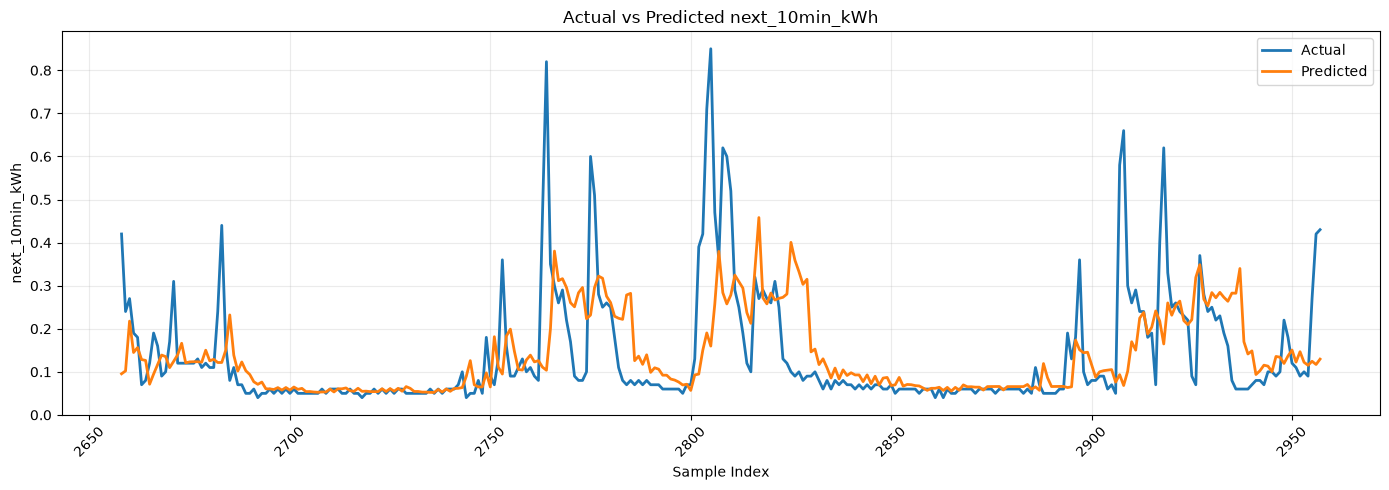

Rows plotted: 300
Actual range: 0.040000 to 0.850000
Predicted range: 0.052150 to 0.458132


In [52]:
# Use best overall model if available
try:
    plot_model_info = best_model_info
except NameError:
    plot_model_info = best_model_info

best_features = plot_model_info["features"]
best_test_predictions = plot_model_info["model"].predict(test_df.loc[:, best_features])

prediction_plot_df = pd.DataFrame(
    {
        "actual": test_df[TARGET_COLUMN].values,
        "predicted": best_test_predictions,
    }
)

# Try to use timestamp if possible
if TIME_COLUMN in test_df.columns:
    parsed_time = pd.to_datetime(test_df[TIME_COLUMN], errors="coerce")

    if parsed_time.notna().sum() > 0:
        prediction_plot_df[TIME_COLUMN] = parsed_time
        use_timestamp = True
    else:
        prediction_plot_df["sample_index"] = np.arange(len(prediction_plot_df))
        use_timestamp = False
        print("Warning: timestamp cannot be parsed. Using sample index for x-axis.")
else:
    prediction_plot_df["sample_index"] = np.arange(len(prediction_plot_df))
    use_timestamp = False
    print("Warning: timestamp column not found. Using sample index for x-axis.")

prediction_plot_df["actual"] = pd.to_numeric(
    prediction_plot_df["actual"],
    errors="coerce"
)

prediction_plot_df["predicted"] = pd.to_numeric(
    prediction_plot_df["predicted"],
    errors="coerce"
)

# Drop only rows where actual/predicted are invalid
prediction_plot_df = (
    prediction_plot_df
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["actual", "predicted"])
    .reset_index(drop=True)
)

if prediction_plot_df.empty:
    raise ValueError(
        "No valid actual/predicted rows are available. "
        "Check test_df target values and model predictions."
    )

plot_rows = min(300, len(prediction_plot_df))
plot_sample = prediction_plot_df.tail(plot_rows).copy().reset_index(drop=True)

if use_timestamp:
    x_values = plot_sample[TIME_COLUMN]
    x_label = "Timestamp"
else:
    x_values = plot_sample["sample_index"] if "sample_index" in plot_sample.columns else np.arange(len(plot_sample))
    x_label = "Sample Index"

plt.figure(figsize=(14, 5))

plt.plot(
    x_values,
    plot_sample["actual"],
    label="Actual",
    linewidth=2,
)

plt.plot(
    x_values,
    plot_sample["predicted"],
    label="Predicted",
    linewidth=2,
)

plt.title("Actual vs Predicted next_10min_kWh")
plt.xlabel(x_label)
plt.ylabel("next_10min_kWh")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Rows plotted: {len(plot_sample)}")
print(
    "Actual range: "
    f"{plot_sample['actual'].min():.6f} to {plot_sample['actual'].max():.6f}"
)
print(
    "Predicted range: "
    f"{plot_sample['predicted'].min():.6f} to {plot_sample['predicted'].max():.6f}")

## 14. Model Registry

Every valid trained profile model is saved as a `.joblib` file. Each model also gets a metadata JSON file containing the feature list, profile name, algorithm, training timestamp, validation/test metrics, target, and proxy dataset warning.


In [54]:
def slugify(value: str) -> str:
    """Create a safe lowercase file-name slug."""
    return (
        value.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )


training_timestamp = datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")
model_registry: List[Dict[str, Any]] = []

for profile_name, model_info in trained_profile_models.items():
    model_filename = f"{profile_name}_{slugify(model_info['algorithm'])}.joblib"
    metadata_filename = f"{profile_name}_{slugify(model_info['algorithm'])}_metadata.json"

    model_path = MODEL_DIR / model_filename
    metadata_path = MODEL_DIR / metadata_filename

    joblib.dump(model_info["model"], model_path)

    metadata = {
        "model_file": str(model_path),
        "metadata_file": str(metadata_path),
        "feature_list": model_info["features"],
        "required_features": model_info["required_features"],
        "optional_features_used": model_info["optional_features_used"],
        "model_profile_name": model_info["profile_name"],
        "model_profile_display_name": model_info["profile_display_name"],
        "algorithm_name": model_info["algorithm"],
        "training_timestamp": training_timestamp,
        "metrics": {
            "validation": model_info["validation_metrics"],
            "test": model_info["test_metrics"],
        },
        "target": TARGET_COLUMN,
        "dataset_note": DATASET_NOTE,
    }

    with open(metadata_path, "w", encoding="utf-8") as metadata_file:
        json.dump(make_json_safe(metadata), metadata_file, indent=2)

    model_registry.append(metadata)

registry_index_path = MODEL_DIR / "model_registry.json"
with open(registry_index_path, "w", encoding="utf-8") as registry_file:
    json.dump(make_json_safe(model_registry), registry_file, indent=2)

registry_df = pd.DataFrame(
    [
        {
            "profile": item["model_profile_display_name"],
            "algorithm": item["algorithm_name"],
            "model_file": item["model_file"],
            "test_MAE": item["metrics"]["test"]["MAE"],
            "test_RMSE": item["metrics"]["test"]["RMSE"],
            "test_MAPE": item["metrics"]["test"]["MAPE"],
            "test_R2": item["metrics"]["test"]["R2"],
        }
        for item in model_registry
    ]
).sort_values("test_MAE")

print(f"Model registry saved to: {registry_index_path}")
display(registry_df)


Model registry saved to: models\model_registry.json


,profile,algorithm,model_file,test_MAE,test_RMSE,test_MAPE,test_R2
1,Medium Proxy Model,XGBRegressor,models\medium_proxy_model_xgbregressor.joblib,0.042592,0.086006,38.932785,0.261202
0,Full Proxy Model,XGBRegressor,models\full_proxy_model_xgbregressor.joblib,0.044875,0.085739,43.358039,0.265781
2,Minimal Proxy Model,GradientBoostingRegressor,models\minimal_proxy_model_gradientboostingreg...,0.062938,0.102665,71.981331,-0.052726


## 15. Local Prediction Function

`predict_next_10min(input_data)` loads registered models, computes timestamp-derived features when possible, computes differences such as `temp_diff`, and selects the best compatible profile in this order:

1. Full Proxy Model
2. Medium Proxy Model
3. Minimal Proxy Model

The function does not silently invent missing lag, rolling, or sensor values. If the available input is only enough for the Minimal Proxy Model, it uses that model. If even the minimal features are unavailable, it returns a clear error.


In [55]:
PROFILE_SELECTION_ORDER = ["full_proxy_model", "medium_proxy_model", "minimal_proxy_model"]


def load_registered_models(models_dir: Path = MODEL_DIR) -> List[Dict[str, Any]]:
    """Load model registry metadata from disk."""
    registry_path = models_dir / "model_registry.json"
    if not registry_path.exists():
        raise FileNotFoundError(
            f"Model registry not found at {registry_path}. "
            "Run the training and model registry cells first."
        )

    with open(registry_path, "r", encoding="utf-8") as registry_file:
        registry = json.load(registry_file)

    return registry


def enrich_prediction_input(input_data: Dict[str, Any]) -> Dict[str, Any]:
    """Derive safe features from the user's input without inventing unavailable values."""
    enriched = dict(input_data)

    if "timestamp" in enriched and enriched["timestamp"] is not None:
        timestamp = pd.to_datetime(enriched["timestamp"], errors="coerce")
        if pd.isna(timestamp):
            raise ValueError("timestamp could not be parsed. Use a value like '2016-05-01 12:00:00'.")
        enriched["hour"] = int(timestamp.hour)
        enriched["day_of_week"] = int(timestamp.dayofweek)
        enriched["is_weekend"] = int(timestamp.dayofweek in [5, 6])
        enriched["month"] = int(timestamp.month)

    if "indoor_temp" in enriched and "outdoor_temp" in enriched and "temp_diff" not in enriched:
        enriched["temp_diff"] = float(enriched["outdoor_temp"]) - float(enriched["indoor_temp"])

    if (
        "indoor_humidity" in enriched
        and "outdoor_humidity" in enriched
        and "humidity_diff" not in enriched
    ):
        enriched["humidity_diff"] = float(enriched["outdoor_humidity"]) - float(enriched["indoor_humidity"])

    return enriched


def missing_features_for_model(input_features: Dict[str, Any], feature_list: List[str]) -> List[str]:
    """Return model features that are missing or null in the input dictionary."""
    missing = []
    for feature in feature_list:
        if feature not in input_features:
            missing.append(feature)
            continue
        value = input_features[feature]
        if value is None:
            missing.append(feature)
            continue
        try:
            if pd.isna(value):
                missing.append(feature)
        except TypeError:
            pass
    return missing


def predict_next_10min(input_data: Dict[str, Any]) -> Dict[str, Any]:
    """Predict next_10min_kWh using the best compatible registered model."""
    registry = load_registered_models(MODEL_DIR)
    enriched_input = enrich_prediction_input(input_data)

    registry_by_profile = {
        profile_name: [
            item
            for item in registry
            if item["model_profile_name"] == profile_name
        ]
        for profile_name in PROFILE_SELECTION_ORDER
    }

    skipped_profiles: Dict[str, List[str]] = {}

    for profile_name in PROFILE_SELECTION_ORDER:
        profile_models = registry_by_profile.get(profile_name, [])
        if not profile_models:
            skipped_profiles[profile_name] = ["No registered model for this profile."]
            continue

        profile_models = sorted(
            profile_models,
            key=lambda item: item["metrics"]["validation"]["MAE"],
        )
        metadata = profile_models[0]
        feature_list = metadata["feature_list"]
        missing_features = missing_features_for_model(enriched_input, feature_list)

        if missing_features:
            skipped_profiles[profile_name] = missing_features
            continue

        model_path = Path(metadata["model_file"])
        if not model_path.is_absolute():
            model_path = Path.cwd() / model_path

        model = joblib.load(model_path)
        prediction_frame = pd.DataFrame(
            [{feature: enriched_input[feature] for feature in feature_list}]
        )
        prediction = float(model.predict(prediction_frame)[0])

        return {
            "predicted_next_10min_kWh": prediction,
            "selected_model_profile": metadata["model_profile_display_name"],
            "model_version": model_path.name,
            "input_features_used": feature_list,
            "missing_features": [],
            "prediction_timestamp": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
            "dataset_warning": "Model was trained on proxy household appliance energy data, not AC-specific data.",
        }

    minimal_models = registry_by_profile.get("minimal_proxy_model", [])
    minimal_required = minimal_models[0]["feature_list"] if minimal_models else PROFILE_DEFINITIONS["minimal_proxy_model"]["required"]

    return {
        "error": "Not enough features are available for any registered model.",
        "required_minimal_features": minimal_required,
        "missing_features": skipped_profiles.get("minimal_proxy_model", minimal_required),
        "skipped_profiles": skipped_profiles,
        "prediction_timestamp": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        "dataset_warning": "Model was trained on proxy household appliance energy data, not AC-specific data.",
    }


## 16. Example Prediction

This example intentionally provides only timestamp and basic environmental readings. That is typically enough for the Minimal Proxy Model, while Full and Medium models often require historical lag and rolling energy features.


In [56]:
example_input = {
    "timestamp": "2016-05-01 12:00:00",
    "indoor_temp": 24.5,
    "outdoor_temp": 32.0,
    "indoor_humidity": 45.0,
    "outdoor_humidity": 55.0,
}

example_prediction = predict_next_10min(example_input)
example_prediction


{'predicted_next_10min_kWh': 0.07430770912820252,
 'selected_model_profile': 'Minimal Proxy Model',
 'model_version': 'minimal_proxy_model_gradientboostingregressor.joblib',
 'input_features_used': ['hour',
  'day_of_week',
  'is_weekend',
  'month',
  'indoor_temp',
  'outdoor_temp',
  'temp_diff'],
 'missing_features': [],
 'prediction_timestamp': '2026-07-08T04:38:31Z',
 'dataset_warning': 'Model was trained on proxy household appliance energy data, not AC-specific data.'}

## 17. Export Summary

The summary below prints the selected best model, core test metrics, and artifact paths.


In [57]:
best_registry_entry = sorted(
    model_registry,
    key=lambda item: item["metrics"]["validation"]["MAE"],
)[0]

best_test_metrics = best_registry_entry["metrics"]["test"]

print("Export Summary")
print("--------------")
print(f"Best model profile: {best_registry_entry['model_profile_display_name']}")
print(f"Best algorithm: {best_registry_entry['algorithm_name']}")
print(f"Test MAE: {best_test_metrics['MAE']:.6f}")
print(f"Test RMSE: {best_test_metrics['RMSE']:.6f}")
print(f"Test MAPE: {best_test_metrics['MAPE']:.6f}")
print(f"Test R2: {best_test_metrics['R2']:.6f}")
print(f"Model path: {best_registry_entry['model_file']}")
print(f"Metrics path: {METRICS_PATH}")
print(f"Audit report path: {AUDIT_REPORT_PATH}")


Export Summary
--------------
Best model profile: Medium Proxy Model
Best algorithm: XGBRegressor
Test MAE: 0.042592
Test RMSE: 0.086006
Test MAPE: 38.932785
Test R2: 0.261202
Model path: models\medium_proxy_model_xgbregressor.joblib
Metrics path: reports\metrics\model_metrics.json
Audit report path: reports\audit\data_audit_report.json


* R2 up, RMSE down

## 18. Limitations and Path to Real AC Forecasting

This model is trained on proxy household appliance energy data, not AC-specific energy data.

It is useful for building and testing the AI pipeline: data loading, dataset adaptation, audit checks, time-series feature engineering, time-ordered splitting, baseline comparison, model training, model registry, evaluation, visualization, and local prediction.

It should not be claimed as a final AC-specific prediction model.

To make this truly AC-specific, future data should include:

- real AC kWh from a smart plug or power meter
- `ac_status`
- `set_temp`
- `ac_mode`
- `fan_speed`
- `room_size`
- `number_people_in_rooms`
- `occupancy_count`
- indoor and outdoor temperature and humidity

Once real AC-specific data is available, the same notebook structure can be reused by replacing `kWh` and `next_10min_kWh` with AC-only energy values and adding AC operation features to the feature profiles.
